In [171]:
from astropy.table import Table
from astropy import units as u
from astropy.constants import c
import astropy.cosmology.units as cu

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import numpy as np

In [172]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel.fits')
loa_rotvel[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,Velocity,V_err,Z_center,c_or_s,bad_map
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,int64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,2,0,85.2570765423194,10360.885795250751,2.8585968152015715e-05,0,0
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,2,0,84501.64562074123,11552.088597267886,3.625595597121146e-05,0,0
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,2,0,282969.52132810064,47353.161076596705,3.9924985924636e-05,1,1
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,2,0,302440.8880562787,28896.31530965247,3.9924985924636e-05,1,1
2389220349968384,67.92758592005009,-12.682644974455277,1.632425063296397,0.00018014046308523026,GALAXY,6.947847135365009,4,TFT,175172,S,0.007399622287542027,0.399999983148231,2,0,463859.8983985996,54059.52550791421,8.115304235316967e-06,0,0


In [173]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [174]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

## get distance from center to fiber in kpc/h

In [175]:
#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

#c in km/s
c = c.to('km/s')

In [177]:
loa_rotvel['r_kpc']= np.nan

for i in np.unique(loa_rotvel['SGA_ID']):

    targ_id = loa_rotvel['SGA_ID'] == i

    sga_id = SGA_dict[i]

    #distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    #convert R26 dist from arcmin to radians
    theta = np.radians((loa_rotvel['DIST_R26'][targ_id])/60)

    z = loa_rotvel['Z'][targ_id]
        
    #distance from us to fiber location
    #d_fiber = (z * c)/H0

    #real distance from center of galaxy to fiber in units kpc/h
    r_fiber = d_center * np.tan(theta) * 1000
    #r_fiber = d_fiber * np.tan(theta) * 1000

    loa_rotvel['r_kpc'][targ_id]=r_fiber

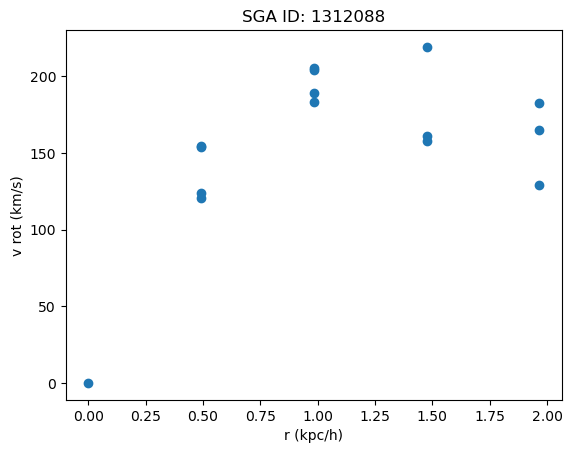

In [178]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers)==0:
        continue

    #r = valid_fibers['DIST_R26']
    r = valid_fibers['r_kpc']
    
    velocity = abs(valid_fibers['Velocity'])

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r, velocity)
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')
    #ax.set_xlim(right=1.04)


In [179]:
def v_rot(r, v_max, r_turn, a):
    return (v_max * r)/(r_turn**a + r**a)**(1/a)

In [202]:
def chi2(params, v_max, r_turn, a):
    v_data, v_err, r = params
    v_model = (v_max * r)/(r_turn**a + r**a)**(1/a)
    return np.sum(((v_data-v_model)/v_err)**2)

0.4437694101250946


/tmp/ipykernel_975728/2780878110.py:3: RuntimeWarning: overflow encountered in power
  v_model = (v_max * r)/(r_turn**a + r**a)**(1/a)
/tmp/ipykernel_975728/2780878110.py:3: RuntimeWarning: divide by zero encountered in divide
  v_model = (v_max * r)/(r_turn**a + r**a)**(1/a)
/tmp/ipykernel_975728/2780878110.py:3: RuntimeWarning: invalid value encountered in divide
  v_model = (v_max * r)/(r_turn**a + r**a)**(1/a)


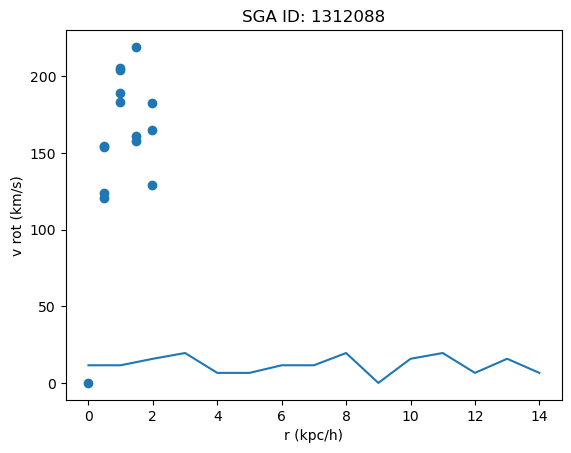

In [231]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers)==0:
        continue

    #r = valid_fibers['DIST_R26']
    r = valid_fibers['r_kpc']
    
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,50),(0.1,1)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [np.max(velocity), r[idx], 1/r[idx]]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args=(velocity, r, v_err), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x

    print(alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r, velocity)
    ax.plot(v_rot(r,vmax_fit, rturn_fit, alpha_fit))
    #ax.errorbar(r, velocity, yerr = v_err)
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')
    #ax.set_xlim(right=1.04)


## Test

In [148]:
loa_rotvel['r_kpc']= np.nan

for i in np.unique(loa_rotvel['SGA_ID']):

    targ_id = loa_rotvel['SGA_ID'] == i

    sga_id = SGA_dict[i]

    #distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    #convert R26 dist from arcmin to radians
    theta = np.radians((loa_rotvel['DIST_R26'][targ_id])/60)

    #real distance from center of galaxy to fiber in units kpc/h
    r_fiber = d_center * np.tan(theta) * 1000

    loa_rotvel['r_kpc'][targ_id]=r_fiber

In [111]:
i = 1312088
sga_id = SGA[SGA['SGA_ID']==i]
sga_id = SGA_dict[i]
print(sga_id)

347984


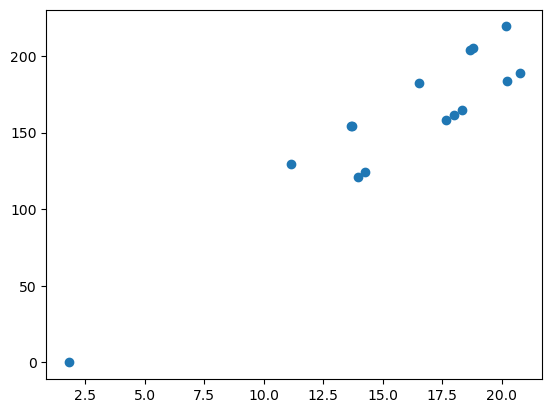

In [128]:
sga_id = 1312088

targ=loa_rotvel[loa_rotvel['SGA_ID']==sga_id]

targ['r_kpc']=0

sga_id = SGA[SGA['SGA_ID']==sga_id]

#distance from us to center of galaxy
d_center = (sga_id['Z_LEDA'] * c)/H0
#print(d_center)

for i in targ:
    z = i['Z']
    
    #distance from us to fiber location
    d_fiber = (z * c)/H0
    #print(d_fiber)

    #convert R26 dist from arcmin to radians
    theta = np.radians(i['DIST_R26']/60)
    #print(theta)

    #real distance from center of galaxy to fiber in units kpc/h
    r_fiber = (np.sqrt((d_center**2)+(d_fiber.value**2)- 2*(d_center)*(d_fiber)*(np.cos(theta))))*10

    #print(r_fiber)

    i['r_kpc']=r_fiber

fig = plt.figure()
ax = fig.add_subplot()
targ_new = targ[abs(targ['Velocity'])<1000]
ax.scatter(targ_new['r_kpc'],abs(targ_new['Velocity']))
#ax.set_xlim(right=1.04)

In [129]:
loa_rotvel['r_kpc']= np.nan

def law_cos(a,b,angle):
    return np.sqrt(a**2 + b**2 - (2*a*b*np.cos(angle)))
    
for i in np.unique(loa_rotvel['SGA_ID']):

    targ_id = loa_rotvel['SGA_ID'] == i

    sga_id = SGA_dict[i]

    #distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    z = loa_rotvel['Z'][targ_id]
        
    #distance from us to fiber location
    d_fiber = (z * c)/H0

    #convert R26 dist from arcmin to radians
    theta = np.radians((loa_rotvel['DIST_R26'][targ_id])/60)

    #real distance from center of galaxy to fiber in units kpc/h
    r_fiber = law_cos(d_center.value,d_fiber.value,theta) *10

    loa_rotvel['r_kpc'][targ_id]=r_fiber